## Preprocessing

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv('../qsar_compact_out/summary_results_external.csv')

# Mapping model names to new abbreviations
model_name_map = {
    'ElasticNet': 'ENT',
    'ExtraTrees': 'ETT',
    'HistGBDT': 'HGT',
    'Lasso': 'LSS',
    'PLSRegression': 'PLS',
    'RandomForest': 'RFT',
    'Ridge': 'RDG',
    'SVR_rbf': 'SVR',
    'XGBoost': 'XGB',
    'BayesianRidge': 'BRG'
}

# Mapping representation languages to new abbreviations
representation_map = {
    'AtomPair_counts': 'APC',
    'Avalon': 'AVN',
    'FeatMorgan2': 'FM2',
    'FeatMorgan3': 'FM3',
    'Mol2Vec_Embeddings': 'M2V',
    'Mordred_2D_Chi_Kappa_EState': 'MK2',
    'RDKFingerprint': 'RDF',
    'Rdkit_PhysChem': 'RDC',
    'Spectrophore_USRCAT': 'SUT',
    'Torsion': 'TSN'
}

# Mapping ChEMBL ID to Gene
chembl_to_gene_map = {
    'CHEMBL3105': 'PARP',
    'CHEMBL1824': 'HER2',
    'CHEMBL4005': 'PI3K',
    'CHEMBL3130': 'PI3K',
    'CHEMBL4282': 'AKT',
    'CHEMBL2842': 'mTOR',
    'CHEMBL3650': 'FGFR1',
    'CHEMBL2742': 'FGFR3',
    'CHEMBL1871': 'AR',
    'CHEMBL203': 'EGFR1',
    'CHEMBL1957': 'IGFR1',
    'CHEMBL4630': 'CHK1',
    'CHEMBL279': 'VEGFR2',
    'CHEMBL4722': 'AURKA',
    'CHEMBL2185': 'AURKB',
    'CHEMBL1865': 'HDAC6'
}

# Apply the mapping to the relevant columns in the dataframe
if 'model' in df.columns:
    df['model'] = df['model'].replace(model_name_map)

if 'representation' in df.columns:
    df['representation'] = df['representation'].replace(representation_map)

# Map dataset (ChEMBL ID) to Gene names
if 'dataset' in df.columns:
    df['dataset'] = df['dataset'].replace(chembl_to_gene_map)

# Save the updated dataframe to the original file
df.to_csv('../qsar_compact_out/summary_results_external.csv', index=False)

print("File saved successfully with updated data!")

File saved successfully with updated data!


## Model and Dataset Ranking and Table [**REVISED**]

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def generate_ranking_analysis(df, metric='R2', output_dir='.'):
    # Pivot table: Dataset x Model, using max() to handle duplicates
    pivot = df.groupby(['dataset', 'model'])[metric].mean().unstack()

    # Filter models with full dataset coverage
    valid_models = pivot.notna().sum() == len(pivot)
    if valid_models.sum() < 2:
        print(f"⚠️ Not enough models with complete coverage. Models must be present in all datasets.")
        return None

    pivot_clean = pivot.loc[:, valid_models]
    print(f"✅ Comparing {valid_models.sum()} models across {len(pivot)} datasets.")

    # Rank models (ascending=False for higher metric = better rank)
    ascending_rank = metric in ['RMSE', 'MAE', 'MSE']
    ranks = pivot_clean.rank(axis=1, ascending=ascending_rank)
    avg_ranks = ranks.mean().sort_values()

    # Plotting
    n_models = len(avg_ranks)
    fig, ax = plt.subplots(figsize=(14, max(4, n_models * 0.4)))  # Increase figure width for more space
    
    # Use the 'viridis' colormap
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_models))  # Apply viridis colormap
    
    ax.barh(np.arange(n_models), avg_ranks.values, color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(np.arange(n_models))
    ax.set_yticklabels(avg_ranks.index, fontsize=13)  # Set y-tick font size to 13
    ax.set_xlabel('Average Rank', fontsize=13)  # Set x-label font size to 13
   
    # Adjust label position to ensure no overlap, especially for the first bar
    for i, v in enumerate(avg_ranks.values):
        if i == 0:  # Special handling for the first bar
            ax.text(v + 0.3, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)  # Increased padding for the first bar
        else:
            ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)  # Normal padding for other bars

    ax.invert_yaxis()
    plt.tight_layout()

    # Save and Show
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path / "MODEL_RANKING_PLOT.png", dpi=600, bbox_inches='tight')
    plt.show()

    # Save rankings to CSV
    rank_df = avg_ranks.to_frame('avg_rank')
    rank_df['std_rank'] = ranks.std()
    rank_df.to_csv(out_path / "MODEL_RANKING_TABLE.csv")

    return rank_df


✅ Comparing 12 models across 15 datasets.


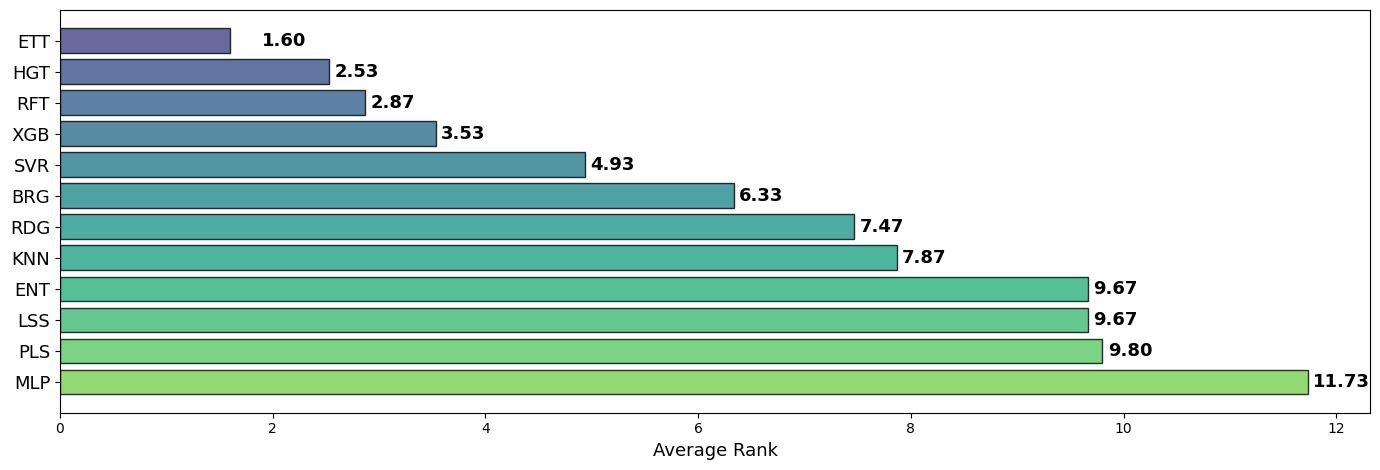

,avg_rank,std_rank
model,,
ETT,1.600000,0.985611
HGT,2.533333,1.187234
RFT,2.866667,0.990430
XGB,3.533333,1.245946
SVR,4.933333,1.579632
BRG,6.333333,0.723747
RDG,7.466667,1.505545
KNN,7.866667,1.959106
ENT,9.666667,1.046536


In [21]:
# Run the analysis
rank_table = generate_ranking_analysis(df, metric='R2')

# Display the table
rank_table

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def generate_ranking_analysis(df, metric='R2', output_dir='.', bar_width=0.8):
    """
    Generate model rankings for datasets based on their performance for each model.
    Calculate the average rank across all models for each dataset.
    
    Args:
        df: Pandas DataFrame containing 'dataset', 'model', and metric columns.
        metric: The column name to rank by (default 'R2').
        output_dir: Directory to save the PNG and CSV files.
        bar_width: Width of the bars in the plot (default 0.8).
        
    Returns:
        pd.DataFrame: The table of dataset ranks averaged across models.
    """
    # Pivot table: Dataset x Model, using max() to handle duplicates
    pivot = df.groupby(['dataset', 'model'])[metric].mean().unstack()

    # Filter datasets with full model coverage
    valid_datasets = pivot.notna().sum(axis=1) == len(pivot.columns)
    if valid_datasets.sum() < 2:
        print(f"⚠️ Not enough datasets with complete model coverage.")
        return None

    pivot_clean = pivot.loc[valid_datasets]
    print(f"✅ Comparing {valid_datasets.sum()} datasets across {len(pivot.columns)} models.")

    # Rank datasets for each model individually
    dataset_ranks = pivot_clean.apply(lambda x: x.rank(ascending=False), axis=0)  # Ranking datasets for each model
    
    # Calculate the average rank for each dataset across all models
    avg_ranks = dataset_ranks.mean(axis=1).sort_values()

    # Plotting the average ranks of datasets
    n_datasets = len(avg_ranks)
    fig, ax = plt.subplots(figsize=(14, max(4, n_datasets * 0.4)))  # Slightly wider figure
    
    # Use 'viridis' colormap for the bar plot
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_datasets))  # Apply viridis colormap
    
    ax.barh(np.arange(n_datasets), avg_ranks.values, color=colors, edgecolor='black', alpha=0.8, height=bar_width)

    ax.set_yticks(np.arange(n_datasets))
    ax.set_yticklabels(avg_ranks.index, fontsize=13)  # Set y-tick font size to 13
    ax.set_xlabel('Average Rank', fontsize=13)  # Set x-label font size to 13
    
    # Add text labels on bars with some padding for the first bar
    for i, v in enumerate(avg_ranks.values):
        if i == 0:  # Check if it's the first bar
            ax.text(v + 0.2, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)  # Add extra padding for the first bar
        else:
            ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)  # Normal padding for other bars

    ax.invert_yaxis()  # Top rank at the top
    plt.tight_layout()

    # Save and Show
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path / "DATASET_RANKING_PLOT.png", dpi=600, bbox_inches='tight')
    plt.show()

    # Save rankings to CSV
    dataset_ranks['avg_rank'] = avg_ranks
    dataset_ranks['std_rank'] = dataset_ranks.std(axis=1)  # Standard deviation of ranks across models
    dataset_ranks.to_csv(out_path / "DATASET_RANKING_TABLE.csv")

    return dataset_ranks


✅ Comparing 15 datasets across 12 models.


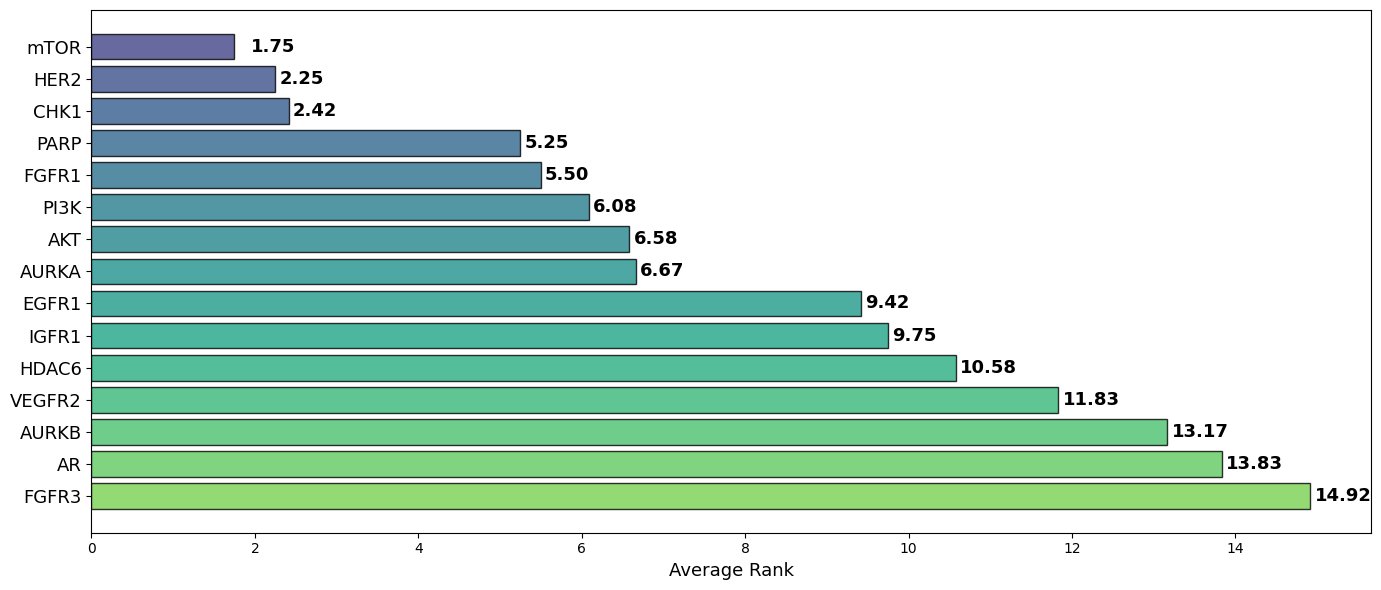

model,BRG,ENT,ETT,HGT,KNN,LSS,MLP,PLS,RDG,RFT,SVR,XGB,avg_rank,std_rank
dataset,,,,,,,,,,,,,,
AKT,8.0,7.0,6.0,8.0,6.0,6.0,4.0,8.0,6.0,6.0,7.0,7.0,6.583333,1.114924
AR,14.0,15.0,14.0,13.0,14.0,14.0,14.0,14.0,14.0,14.0,13.0,13.0,13.833333,0.552771
AURKA,6.0,9.0,7.0,7.0,8.0,4.0,5.0,4.0,4.0,8.0,10.0,8.0,6.666667,1.972027
AURKB,13.0,13.0,13.0,14.0,13.0,13.0,13.0,12.0,13.0,13.0,14.0,14.0,13.166667,0.552771
CHK1,3.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,1.0,2.416667,0.640095
EGFR1,11.0,10.0,9.0,9.0,9.0,10.0,6.0,11.0,11.0,9.0,9.0,9.0,9.416667,1.320248
FGFR1,5.0,5.0,4.0,4.0,4.0,8.0,9.0,5.0,7.0,5.0,5.0,5.0,5.500000,1.554563
FGFR3,15.0,14.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.0,14.916667,0.276385
HDAC6,10.0,11.0,10.0,10.0,12.0,11.0,11.0,10.0,10.0,11.0,11.0,10.0,10.583333,0.640095


In [ ]:
# Load your data
df = pd.read_csv('../qsar_compact_out/summary_results_external.csv')

# Run the analysis
rank_table = generate_ranking_analysis(df, metric='R2')

# Display the table
rank_table

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def generate_representation_ranking(df, metric='R2', output_dir='.'):
    """
    Generate rankings for Chemical Representations based on MEAN performance across models.
    """
    # Mapping
    representation_map = {
        'AtomPair_counts': 'APC', 'Avalon': 'AVN', 'FeatMorgan2': 'FM2',
        'FeatMorgan3': 'FM3', 'Mol2Vec_Embeddings': 'M2V',
        'Mordred_2D_Chi_Kappa_EState': 'MK2', 'RDKFingerprint': 'RDF',
        'Rdkit_PhysChem': 'RDC', 'Spectrophore_USRCAT': 'SUT', 'Torsion': 'TSN'
    }
    
    # Apply map if column exists
    if 'representation' in df.columns:
        df['representation'] = df['representation'].replace(representation_map)

    # --- CRITICAL FIX: Use mean() instead of max() ---
    # We want the average performance of a representation across ALL models
    # before we compare it to other representations.
    pivot = df.groupby(['representation', 'dataset'])[metric].mean().unstack()

    # Filter for full coverage
    valid_reps = pivot.notna().sum(axis=1) == len(pivot.columns)
    if valid_reps.sum() < 2:
        print(f"⚠️ Not enough representations with complete dataset coverage.")
        return None

    pivot_clean = pivot.loc[valid_reps]
    print(f"✅ Ranking {valid_reps.sum()} representations across {len(pivot.columns)} datasets.")

    # --- RANKING LOGIC ---
    # R2: Higher is Better -> ascending=False (High val gets Rank 1)
    # RMSE: Lower is Better -> ascending=True (Low val gets Rank 1)
    is_error = metric in ['RMSE', 'MAE', 'MSE']
    
    # Calculate Rank per Dataset (Judge)
    # method='min' means if two tie for best, both get rank 1
    rep_ranks = pivot_clean.rank(axis=0, ascending=is_error, method='min')
    
    # Calculate Average Rank across all datasets
    avg_ranks = rep_ranks.mean(axis=1).sort_values() # sort so best (lowest rank) is first

    # --- PLOTTING ---
    n_reps = len(avg_ranks)
    fig, ax = plt.subplots(figsize=(12, max(4, n_reps * 0.5)))
    
    # Create Bars
    # We want Rank 1 to look "Best". 
    # Standard bar chart: Longer = Higher Value (Worse Rank).
    # We will stick to standard representation but label clearly.
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_reps))
    bars = ax.barh(np.arange(n_reps), avg_ranks.values, color=colors, edgecolor='black', alpha=0.8)

    # Style
    ax.grid(False)
    ax.set_yticks(np.arange(n_reps))
    ax.set_yticklabels(avg_ranks.index, fontsize=13)
    
    # Invert Y axis so Best (#1) is at the top
    ax.invert_yaxis()
    
    # Axis Labels
    ax.set_xlabel('Average Rank (Lower is Better)', fontsize=13)
    
    # Add numeric labels
    for i, v in enumerate(avg_ranks.values):
        ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=12)

    plt.tight_layout()

    # Save
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    
    filename = "CHEMICAL_RANKING_PLOT.png" 
    plt.savefig(out_path / filename, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"   🖼️ Saved ranking plot: {filename}")

    # Save CSV
    rep_ranks['avg_rank'] = avg_ranks
    rep_ranks.to_csv(out_path / "CHEMICAL_RANKING_TABLE.csv")

    return rep_ranks
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')
# generate_representation_ranking(df, metric='R2')


✅ Ranking 12 representations across 15 datasets.


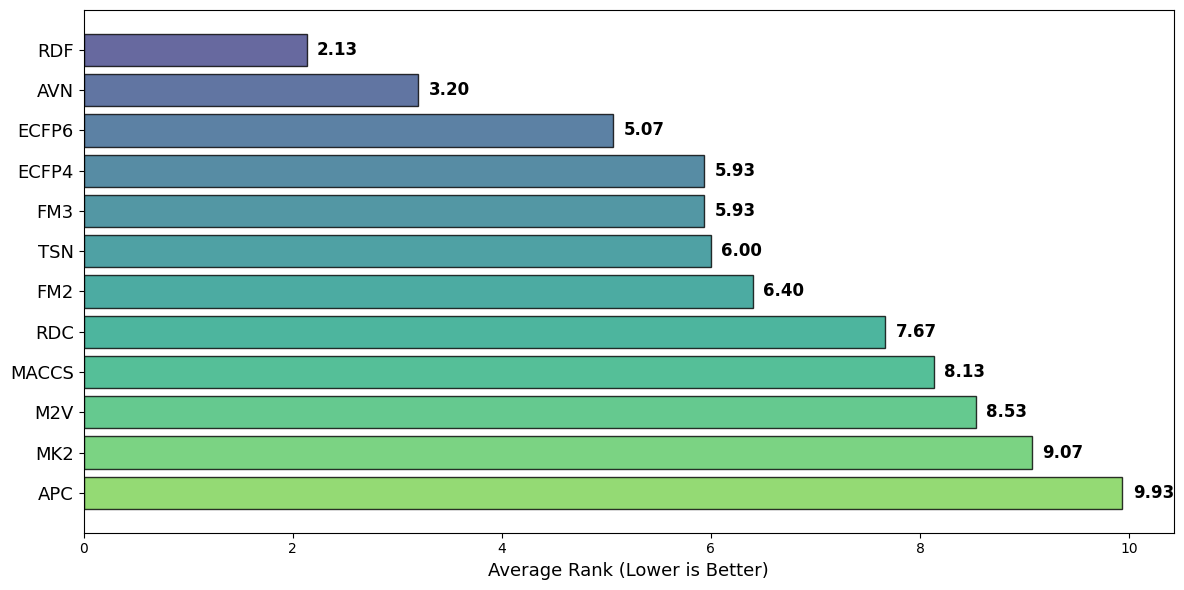

   🖼️ Saved ranking plot: CHEMICAL_RANKING_PLOT.png


dataset,AKT,AR,AURKA,AURKB,CHK1,EGFR1,FGFR1,FGFR3,HDAC6,HER2,IGFR1,PARP,PI3K,VEGFR2,mTOR,avg_rank
representation,,,,,,,,,,,,,,,,
APC,9.0,8.0,8.0,7.0,12.0,12.0,9.0,9.0,11.0,11.0,12.0,11.0,8.0,11.0,11.0,9.933333
AVN,3.0,4.0,3.0,4.0,2.0,7.0,3.0,1.0,5.0,2.0,2.0,3.0,4.0,3.0,2.0,3.200000
ECFP4,4.0,11.0,4.0,10.0,7.0,3.0,2.0,8.0,6.0,9.0,9.0,2.0,3.0,6.0,5.0,5.933333
ECFP6,1.0,9.0,5.0,12.0,4.0,2.0,4.0,10.0,2.0,6.0,5.0,6.0,2.0,4.0,4.0,5.066667
FM2,5.0,5.0,6.0,8.0,5.0,5.0,7.0,12.0,10.0,10.0,1.0,7.0,7.0,5.0,3.0,6.400000
FM3,6.0,10.0,2.0,11.0,3.0,4.0,6.0,11.0,3.0,8.0,7.0,4.0,5.0,2.0,7.0,5.933333
M2V,10.0,1.0,10.0,5.0,10.0,10.0,8.0,6.0,8.0,12.0,11.0,8.0,9.0,8.0,12.0,8.533333
MACCS,12.0,6.0,11.0,1.0,11.0,9.0,11.0,2.0,9.0,7.0,4.0,9.0,12.0,10.0,8.0,8.133333
MK2,11.0,2.0,12.0,6.0,8.0,11.0,12.0,7.0,12.0,4.0,10.0,12.0,11.0,9.0,9.0,9.066667


In [19]:
generate_representation_ranking(df, metric='R2')

## Model and Dataset Difficulty and Agreement [**SEMI-REVISED**]

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

def analyze_dataset_difficulty(df, output_dir=None):
    """
    Calculates dataset difficulty and model disagreement, then generates plots.
    
    Args:
        df: The dataframe containing 'dataset', 'model', and 'R2' columns.
        output_dir: (Optional) Path to save the PNG/CSV.
        
    Returns:
        pd.DataFrame: A dataframe sorted by difficulty with metrics.
    """
    print("Analyzing dataset difficulty and model disagreement...")

    # --- 1. Calculate Metrics using GroupBy ---
    dataset_stats = df.groupby('dataset')['R2'].agg(['max', 'std', 'mean', 'count']).reset_index()

    # Rename columns to match the logic
    dataset_stats.columns = ['dataset', 'best_R2', 'model_variance', 'mean_R2', 'n_models']

    # Calculate Difficulty Score (1 - Best R2)
    dataset_stats['difficulty_score'] = 1 - dataset_stats['best_R2']

    # Sort by Difficulty (Hardest first)
    difficulty_df = dataset_stats.sort_values('difficulty_score', ascending=False).reset_index(drop=True)

    # Handle Output Directory
    if output_dir is None:
        output_dir = "."
    out_path = pathlib.Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Save CSV (As promised in docstring)
    difficulty_df.to_csv(out_path / "dataset_difficulty_metrics.csv", index=False)

    # --- 2. Generate Plots ---
    
    # === Plot A: Top 20 Most Difficult Datasets ===
    fig, ax = plt.subplots(figsize=(15, 6))
    top_n = min(20, len(difficulty_df))
    top_diff = difficulty_df.head(top_n)

    # Color map
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))

    ax.barh(range(top_n), top_diff['difficulty_score'], color=colors, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_diff['dataset'], fontsize=13)
    ax.set_xlabel('Difficulty Score (1 - Best R²)', fontsize=13)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    # FIX 1: Expand X-axis limits for bar chart
    max_val = top_diff['difficulty_score'].max()
    ax.set_xlim(0, max_val * 1.15)
    
    # Dynamic padding
    x_offset = max_val * 0.01

    for i, v in enumerate(top_diff['difficulty_score']):
        ax.text(v + x_offset, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)

    plt.tight_layout()
    plt.savefig(out_path / "DATASET_DIFFICULTY_PLOT.png", dpi=600)
    print(f"Saved results to {output_dir}/DATASET_DIFFICULTY_PLOT.png")
    plt.close()

    # === Plot B: Datasets with Highest Model Disagreement (Variance) ===
    fig, ax = plt.subplots(figsize=(15, 6))
    disagreement_df = difficulty_df.sort_values('model_variance', ascending=False).head(top_n)

    colors_var = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))

    ax.barh(range(top_n), disagreement_df['model_variance'], color=colors_var, edgecolor='black', alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(disagreement_df['dataset'], fontsize=13)
    ax.set_xlabel('Standard Deviation of R² (Model Disagreement)', fontsize=13)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    # FIX 2: Expand X-axis limits for disagreement plot
    max_val_var = disagreement_df['model_variance'].max()
    ax.set_xlim(0, max_val_var * 1.15)

    # Dynamic padding
    x_offset_var = max_val_var * 0.01

    for i, v in enumerate(disagreement_df['model_variance']):
        ax.text(v + x_offset_var, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=13)

    plt.tight_layout()
    plt.savefig(out_path / "DATASET_DISAGREEMENT_PLOT.png", dpi=600)
    print(f"Saved results to {output_dir}/DATASET_DISAGREEMENT_PLOT.png")
    plt.close()

    # === Plot C: Scatter Plot ===
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    scatter = ax2.scatter(difficulty_df['difficulty_score'], 
                          difficulty_df['model_variance'],
                          c=difficulty_df['best_R2'], 
                          cmap='viridis',
                          s=60, alpha=0.7, edgecolors='black')

    ax2.set_xlabel('Dataset Hardness (1 - Best R²)', fontsize=13)
    ax2.set_ylabel('Model Disagreement (Std Dev)', fontsize=13)

    # FIX 3: Explicitly set limits for scatter plot to prevent label cutoff
    # Get current data ranges
    x_min, x_max = difficulty_df['difficulty_score'].min(), difficulty_df['difficulty_score'].max()
    y_min, y_max = difficulty_df['model_variance'].min(), difficulty_df['model_variance'].max()
    
    # Add 10% padding to the max values
    x_range = x_max - x_min
    y_range = y_max - y_min
    ax2.set_xlim(x_min - (x_range*0.05), x_max + (x_range*0.15)) # Extra space on right for text
    ax2.set_ylim(y_min - (y_range*0.05), y_max + (y_range*0.1))

    cbar = plt.colorbar(scatter, ax=ax2, label='Best R²')
    cbar.ax.tick_params(labelsize=13)

    # Annotate points
    for _, row in difficulty_df.iterrows():
        ax2.annotate(row['dataset'][:15], 
                     (row['difficulty_score'], row['model_variance']),
                     xytext=(5, 5), textcoords='offset points', fontsize=13)

    fig2.tight_layout()
    plt.savefig(out_path / "DATASET_DIFFICULTY_DISAGREEMENT_PLOT.png", dpi=600)
    print(f"Saved results to {output_dir}/DATASET_DIFFICULTY_DISAGREEMENT_PLOT.png")
    # plt.show() # Optional: Commented out for batch processing

    return difficulty_df

Analyzing dataset difficulty and model disagreement...
Saved results to ./DATASET_DIFFICULTY_PLOT.png
Saved results to ./DATASET_DISAGREEMENT_PLOT.png
Saved results to ./DATASET_DIFFICULTY_DISAGREEMENT_PLOT.png
Top Hardest Datasets:


,dataset,best_R2,model_variance,mean_R2,n_models,difficulty_score
0,FGFR3,0.271003,0.278825,0.016113,156,0.728997
1,AR,0.501054,0.203721,0.210290,156,0.498946
2,AURKB,0.513327,0.158066,0.257248,156,0.486673
3,VEGFR2,0.524528,0.110942,0.333591,153,0.475472
4,IGFR1,0.593384,0.202060,0.416273,156,0.406616
5,EGFR1,0.624754,0.124519,0.424123,144,0.375246
6,HDAC6,0.639355,0.178545,0.399576,156,0.360645
7,AKT,0.674398,0.129698,0.502910,156,0.325602
8,AURKA,0.684255,0.139740,0.491694,156,0.315745
9,PARP,0.694918,0.141955,0.512978,156,0.305082



Top Datasets with Highest Disagreement:


,dataset,best_R2,model_variance,mean_R2,n_models,difficulty_score
0,FGFR3,0.271003,0.278825,0.016113,156,0.728997
1,AR,0.501054,0.203721,0.210290,156,0.498946
4,IGFR1,0.593384,0.202060,0.416273,156,0.406616
6,HDAC6,0.639355,0.178545,0.399576,156,0.360645
14,FGFR1,0.735296,0.167897,0.510464,156,0.264704
2,AURKB,0.513327,0.158066,0.257248,156,0.486673
12,PI3K,0.729189,0.150173,0.506557,309,0.270811
9,PARP,0.694918,0.141955,0.512978,156,0.305082
8,AURKA,0.684255,0.139740,0.491694,156,0.315745
11,HER2,0.728410,0.138232,0.572239,156,0.271590


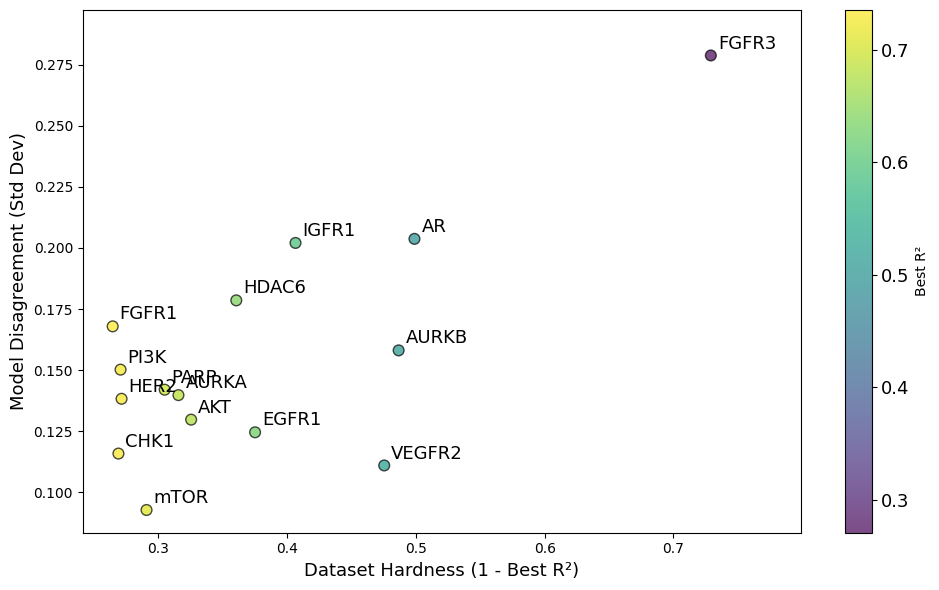

In [15]:
# 1. Run the analysis
diff_df = analyze_dataset_difficulty(df)

# 2. Inspect the hardest datasets
print("Top Hardest Datasets:")
display(diff_df)

# 3. Inspect datasets with highest disagreement (where models fought the most)
print("\nTop Datasets with Highest Disagreement:")
display(diff_df.sort_values('model_variance', ascending=False))

## Metric Statistics [**REVISED**]

In [22]:
import pandas as pd

def generate_dataset_statistics(df, output_file="DATASET_STATISTICS_TABLE.csv"):
    """
    Generates a statistical summary (mean, std, min, max) for specific QSAR metrics
    grouped by dataset.
    """
    # 1. Define the exact metrics you want to analyze
    target_metrics = [
        'R2', 'Q2', 'RMSE', 'MAE', 
        'Spearman', 'Pearson', 'CCC', 
        'rm2_avg', 'within_1.0_log'
    ]
    
    # 2. Filter: Only use metrics that actually exist in your DataFrame
    # (Prevents errors if a column like 'rm2_avg' is missing)
    available_metrics = [m for m in target_metrics if m in df.columns]
    
    if not available_metrics:
        print("⚠️ Error: None of the requested metrics were found in the DataFrame.")
        return None

    print(f"Aggregating statistics for: {available_metrics}")

    # 3. Group and Aggregate
    # This creates a Multi-Index column structure: ('R2', 'mean'), ('R2', 'std'), etc.
    grouped = df.groupby('dataset')[available_metrics].agg(['mean', 'std', 'min', 'max'])
    
    # 4. Flatten the Columns
    # Converts (Metric, Stat) -> "Metric_Stat" (e.g., "R2_mean")
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    
    # 5. Reset Index
    # Makes 'dataset' the first column instead of the index
    final_df = grouped.reset_index()
    
    # 6. Save to CSV
    final_df.to_csv(output_file, index=False)
    print(f"✅ Dataset summary saved to: {output_file}")
    
    return final_df

In [23]:
summary_stats_df = generate_dataset_statistics(df)

# Display the first few rows to verify it matches your desired format
summary_stats_df.head()

Aggregating statistics for: ['R2', 'Q2', 'RMSE', 'MAE', 'Spearman', 'Pearson', 'CCC', 'rm2_avg', 'within_1.0_log']
✅ Dataset summary saved to: DATASET_STATISTICS_TABLE.csv


,dataset,R2_mean,R2_std,R2_min,R2_max,Q2_mean,Q2_std,Q2_min,Q2_max,RMSE_mean,...,CCC_min,CCC_max,rm2_avg_mean,rm2_avg_std,rm2_avg_min,rm2_avg_max,within_1.0_log_mean,within_1.0_log_std,within_1.0_log_min,within_1.0_log_max
0,AKT,0.502910,0.129698,-0.000364,0.674398,0.502910,0.129698,-0.000364,0.674398,0.867439,...,-1.669921e-31,0.811532,8.284114e+08,1.034685e+10,-0.046239,1.292322e+11,76.830697,5.595003,54.420432,84.313725
1,AR,0.210290,0.203721,-0.857279,0.501054,0.210290,0.203721,-0.857279,0.501054,0.789603,...,5.029791e-31,0.666214,4.147739e+11,5.180525e+12,-0.415419,6.470473e+13,80.231749,5.706157,60.754717,88.931298
2,AURKA,0.491694,0.139740,0.017765,0.684255,0.491694,0.139740,0.017765,0.684255,0.910518,...,2.158884e-02,0.808599,3.239422e-01,1.573686e-01,-0.332511,5.325885e-01,74.019427,7.186903,54.814815,84.184915
3,AURKB,0.257248,0.158066,-0.851853,0.513327,0.257248,0.158066,-0.851853,0.513327,0.958807,...,7.903936e-02,0.671907,8.374533e-02,7.702473e-02,-0.258897,3.231184e-01,71.913602,6.002042,53.005464,81.992337
4,CHK1,0.574352,0.115807,0.123404,0.730825,0.574352,0.115807,0.123404,0.730825,0.905258,...,4.800287e-01,0.853055,4.028563e-01,1.340178e-01,0.042669,6.553858e-01,72.330471,6.510331,54.651163,83.815029


##  Chemical - Model Performance [**REVISED**]

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pathlib

def performance_heatmap(df, metric='R2', output_dir='.'):
    """
    Generates heatmaps with added Row and Column averages for 
    both Dataset and Representation analysis.
    """
    
    # Create output directory if it doesn't exist
    out_path = pathlib.Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Use viridis_r if plotting Error (RMSE/MAE) (Low = Good), otherwise viridis (High = Good)
    cmap = 'viridis_r' if metric in ['RMSE', 'MAE'] else 'viridis'

    # Helper function to add averages and plot
    def plot_with_averages(pivot_df, filename_prefix, xlabel, ylabel):
        # ---------------------------------------------------------
        # ADDING AVERAGES
        # ---------------------------------------------------------
        # 1. Add Column for Row Averages
        pivot_df['Average'] = pivot_df.mean(axis=1)
        
        # 2. Add Row for Column Averages 
        # (We calculate mean of the df which now includes the row average column)
        pivot_df.loc['Average'] = pivot_df.mean(axis=0)
        # ---------------------------------------------------------

        # Dynamic height
        h = max(8, len(pivot_df) * 0.5)
        plt.figure(figsize=(14, h))
        
        # Generate the heatmap
        ax = sns.heatmap(pivot_df, annot=True, cmap=cmap, fmt=".3f", 
                         linewidths=.5, annot_kws={'size': 10}, 
                         cbar_kws={'label': f'{metric} Value'})
        
        # VISUAL SEPARATORS: Draw lines to separate the "Average" row/col
        # The 'Average' column is the last one (index = width - 1)
        # The 'Average' row is the last one (index = height - 1)
        rows, cols = pivot_df.shape
        
        # Vertical line separating the last column
        ax.vlines(x=cols - 1, ymin=0, ymax=rows, colors='white', linewidth=4)
        # Horizontal line separating the last row
        ax.hlines(y=rows - 1, xmin=0, xmax=cols, colors='white', linewidth=4)

        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.tick_params(axis='both', labelsize=11)
        
        # Fix overlapping y-labels if the list is long
        plt.yticks(rotation=0) 

        # Colorbar settings
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=13)
        cbar.set_label(f'{metric} Value', fontsize=14)
        
        plt.tight_layout()
        plt.savefig(out_path / f"{filename_prefix}_PLOT.png", dpi=600)
        plt.close()
        
        pivot_df.to_csv(out_path / f"{filename_prefix}_TABLE.csv")
        print(f"Saved {filename_prefix} table and plot.")

    # --- 1. DATASET HEATMAP (Dataset vs Model) ---
    print(f"1. Generating Dataset Heatmap ({metric})...")
    # Pivot the data: Rows=Dataset, Columns=Model
    # Note: aggfunc='max' picks the best run if there are duplicates, 
    # but the averages calculated inside the helper will average these max values.
    pivot_data = df.pivot_table(index='dataset', columns='model', values=metric, aggfunc='max')
    
    plot_with_averages(pivot_data, "DATASET_PERFORMANCE", "Model Architecture", "Dataset")

    # --- 2. REPRESENTATION HEATMAP (Representation vs Model) ---
    if 'representation' in df.columns:
        print(f"2. Generating Representation Heatmap ({metric})...")
        # Pivot: Rows=Representation, Columns=Model
        pivot_rep = df.pivot_table(index='representation', columns='model', values=metric, aggfunc='mean')
        
        plot_with_averages(pivot_rep, "CHEMICAL_PERFORMANCE", "Model Architecture", "Chemical Representation")
    else:
        print("Skipping Representation Heatmap: 'representation' column not found.")

    print(f"All heatmaps and tables saved to {output_dir}")


In [25]:
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')  # Load your dataframe if needed
# Call the function to generate heatmaps
performance_heatmap(df, metric='R2')


1. Generating Dataset Heatmap (R2)...
Saved DATASET_PERFORMANCE table and plot.
2. Generating Representation Heatmap (R2)...
Saved CHEMICAL_PERFORMANCE table and plot.
All heatmaps and tables saved to .


## Box Plots MAE by Model, Class and Dataset [**REVISED**]

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pathlib
import numpy as np

def plot_mae_boxplots(df, output_dir='.'):
    """
    Generates three separate box plots for MAE distribution:
    1. By Model
    2. By Dataset
    3. By Chemical Representation
    
    Args:
        df: Pandas DataFrame containing 'MAE', 'model', 'dataset', and optional 'representation' columns.
        output_dir: Directory to save the generated plots.
    """
    
    # Check if MAE exists
    if 'MAE' not in df.columns:
        print("Error: 'MAE' column not found in DataFrame.")
        return

    # Create output directory if it doesn't exist
    out_path = pathlib.Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    # Set global seaborn theme for consistent design
    sns.set(style="whitegrid", palette="viridis")

    # ==========================================
    # 1. MAE by MODEL
    # ==========================================
    # Sort models by Median MAE (Lowest/Best on top)
    order_model = df.groupby('model')['MAE'].median().sort_values(ascending=True).index
    
    # Dynamic height based on number of models
    h_model = max(6, len(order_model) * 0.5)
    
    plt.figure(figsize=(10, h_model))
    sns.boxplot(data=df, x='MAE', y='model', order=order_model, 
                palette="viridis", linewidth=1.2)
    
    # Set labels and font sizes
    plt.xlabel('Mean Absolute Error', fontsize=14)
    plt.ylabel('Model Architecture', fontsize=14)
    plt.tight_layout()
    
    # Save the plot to the output directory with 600 DPI
    plt.savefig(out_path / "MODEL_ERROR_PLOT.png", dpi=600)
    plt.close()

    # ==========================================
    # 2. MAE by DATASET
    # ==========================================
    # Sort datasets by Median MAE (Easiest on top, Hardest on bottom)
    order_dataset = df.groupby('dataset')['MAE'].median().sort_values(ascending=True).index
    
    # Dynamic height
    h_data = max(8, len(order_dataset) * 0.4)
    
    plt.figure(figsize=(10, h_data))
    sns.boxplot(data=df, x='MAE', y='dataset', order=order_dataset, 
                palette="viridis", linewidth=0.8)
    
    # Set labels and font sizes
    plt.xlabel('Mean Absolute Error', fontsize=14)
    plt.ylabel('Dataset', fontsize=14)
    plt.tight_layout()
    
    # Save the plot to the output directory with 600 DPI
    plt.savefig(out_path / "DATASET_ERROR_PLOT.png", dpi=600)
    plt.close()

    # ==========================================
    # 3. MAE by CHEMICAL REPRESENTATION
    # ==========================================
    if 'representation' in df.columns:
        # Sort representations by Median MAE
        order_rep = df.groupby('representation')['MAE'].median().sort_values(ascending=True).index
        
        plt.figure(figsize=(10, max(5, len(order_rep) * 0.8)))
        sns.boxplot(data=df, x='MAE', y='representation', order=order_rep, 
                    palette="viridis", linewidth=1.2)
        
        # Set labels and font sizes
        plt.xlabel('Mean Absolute Error', fontsize=14)
        plt.ylabel('Representation Type', fontsize=14)
        plt.tight_layout()
        
        # Save the plot to the output directory with 600 DPI
        plt.savefig(out_path / "CHEMICAL_ERROR_PLOT.png", dpi=600)
        plt.close()
    else:
        print("Skipping Representation plot: 'representation' column not found.")

    print(f"All plots saved to {output_dir}")


In [27]:
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')  # Load your dataframe if needed
plot_mae_boxplots(df)


C:\Users\raula\AppData\Local\Temp\ipykernel_356320\2997170191.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MAE', y='model', order=order_model,
C:\Users\raula\AppData\Local\Temp\ipykernel_356320\2997170191.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MAE', y='dataset', order=order_dataset,
C:\Users\raula\AppData\Local\Temp\ipykernel_356320\2997170191.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MAE', y='representation', order=order_rep,


All plots saved to .


## Bar Plots statistics by Model, Class and Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def generate_styled_comparison_plots(df, output_dir='.'):
    """
    Generates 2-panel comparison plots (R2 and RMSE) with the following:
    - All fonts are set to 14
    - No titles
    - 600 DPI output
    - Reduced height for the plots
    """
    # 1. Setup Output
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    print(f"📂 Saving high-res styled plots to: {out_path.absolute()}")
    
    # Define the metrics (only R2 and RMSE)
    available_metrics = ['R2', 'RMSE']
    
    # Check if the necessary metrics are in the dataframe
    if not all(metric in df.columns for metric in available_metrics):
        print("❌ Not enough metrics (R2 and RMSE) to generate plots.")
        return
    
    # Define categories (Model, Dataset)
    categories = ['model', 'dataset', "representation"]
    
    # 2. Main Loop (Per Category)
    for category in categories:
        # Skip if category column doesn't exist
        if category not in df.columns:
            continue

        print(f"\n--- Processing {category.upper()} ---")
        
        # Save Summary Table First
        stats = df.groupby(category)[available_metrics].mean().reset_index()
        stats.to_csv(out_path / f"{category.upper()}_METRICS_TABLE.csv", index=False)
        
        # Calculate Layout
        n_rows = 1  # Only two metrics (R2 and RMSE)
        n_cols = 2  # Two columns
        
        # Dynamic height based on the number of items in the category (shortened)
        n_items = df[category].nunique()
        row_factor = 0.3 if category == 'dataset' else 0.6  # Reduced height factor
        fig_height = max(4, n_items * row_factor * 1.2)  # Make it shorter than before
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, fig_height))
        axes = axes.flatten()
        
        for idx, metric in enumerate(available_metrics):
            ax = axes[idx]
            
            # --- Sorting Logic ---
            is_error = metric == 'RMSE'  # RMSE is an error metric, lower is better
            
            if is_error:
                plot_data = df.groupby(category)[metric].mean().sort_values(ascending=False)
            else:
                plot_data = df.groupby(category)[metric].mean().sort_values(ascending=True)
            
            # --- Styling Logic ---
            n_bars = len(plot_data)
            # Generate Viridis colors from 0.2 to 0.8
            colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_bars))
            
            bars = ax.barh(np.arange(n_bars), plot_data.values, 
                           color=colors, 
                           edgecolor='black', 
                           alpha=0.8)
            
            ax.set_yticks(np.arange(n_bars))
            ax.set_yticklabels(plot_data.index, fontsize=14)  # Set all font to 14
            ax.set_xlabel(f'Mean {metric}', fontsize=14)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            
            # FIX: Expand x-axis to prevent label cutoff
            # We find the maximum bar length and add 15% buffer space to the right
            max_val = plot_data.values.max()
            ax.set_xlim(0, max_val * 1.15)

            # Define offset based on the data, not the plot limits
            offset = max_val * 0.01
            
            # Add Bold Value Labels
            for i, v in enumerate(plot_data.values):
                ax.text(v + offset, i, f'{v:.2f}', va='center', 
                        fontweight='bold', fontsize=14)

        # Hide empty subplots
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        
        # Save High Res
        filename = f"{category.upper()}_METRICS_PLOT.png"
        plt.savefig(out_path / filename, dpi=600, bbox_inches='tight')  # Save as 600 DPI
        plt.close()
        print(f"   🖼️ Saved: {filename}")

    print("\n✅ Styled analysis complete.")

In [13]:
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')
generate_styled_comparison_plots(df)

📂 Saving high-res styled plots to: c:\Users\raula\Documents\QSAR\figures

--- Processing MODEL ---
   🖼️ Saved: MODEL_METRICS_PLOT.png

--- Processing DATASET ---
   🖼️ Saved: DATASET_METRICS_PLOT.png

--- Processing REPRESENTATION ---
   🖼️ Saved: REPRESENTATION_METRICS_PLOT.png

✅ Styled analysis complete.


## Nemenyi Test [**REVISED**]

--- STARTING STATISTICAL ANALYSIS (R2) ---
✅ Running Nemenyi on 12 MODELs.
   📄 Saved Table: MODEL_NEMENYI_TABLE.csv


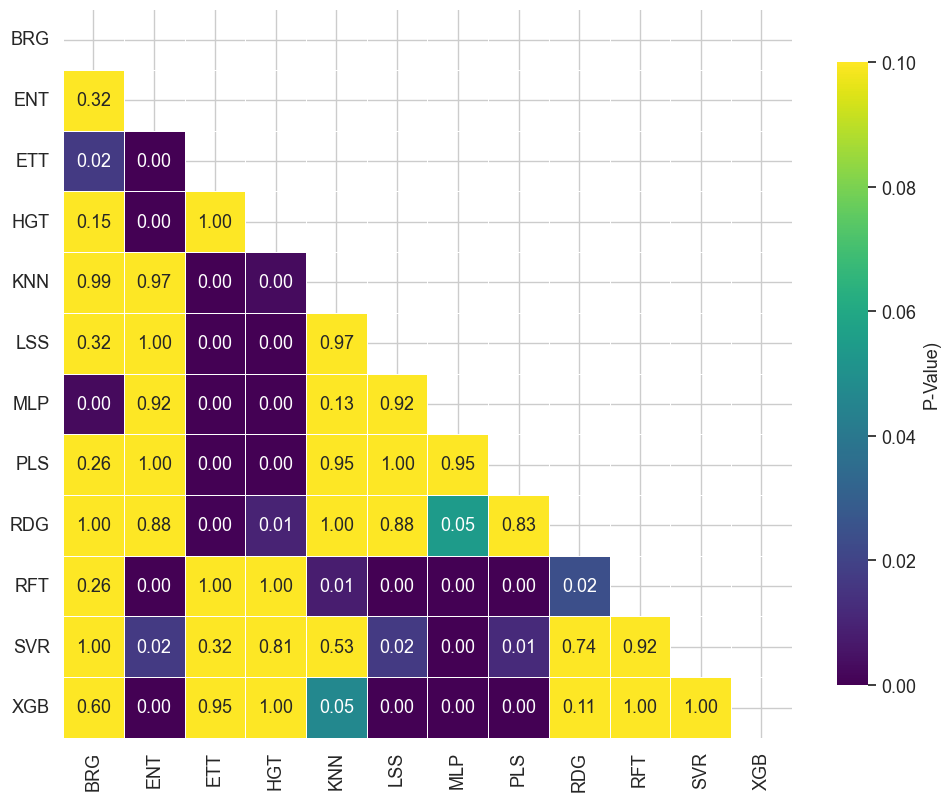

   🖼️  Saved Plot: MODEL_NEMENYI_PLOT.png
✅ Running Nemenyi on 12 CHEMICALs.
   📄 Saved Table: CHEMICAL_NEMENYI_TABLE.csv


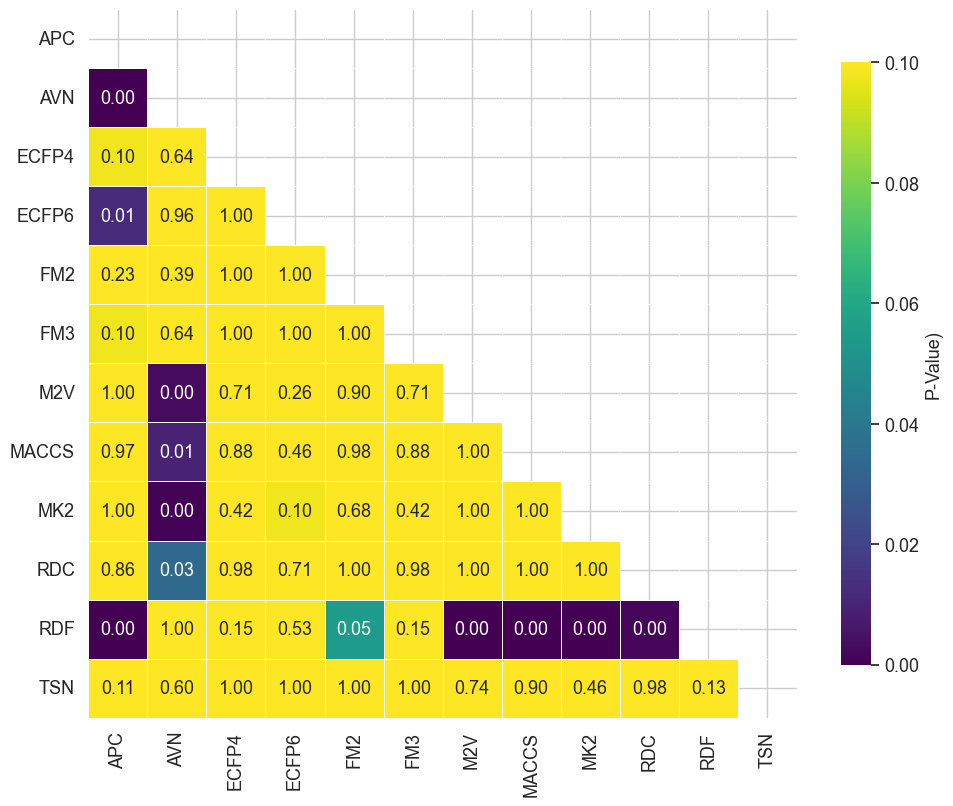

   🖼️  Saved Plot: CHEMICAL_NEMENYI_PLOT.png
✅ Running Nemenyi on 15 DATASETs.
   📄 Saved Table: DATASET_NEMENYI_TABLE.csv


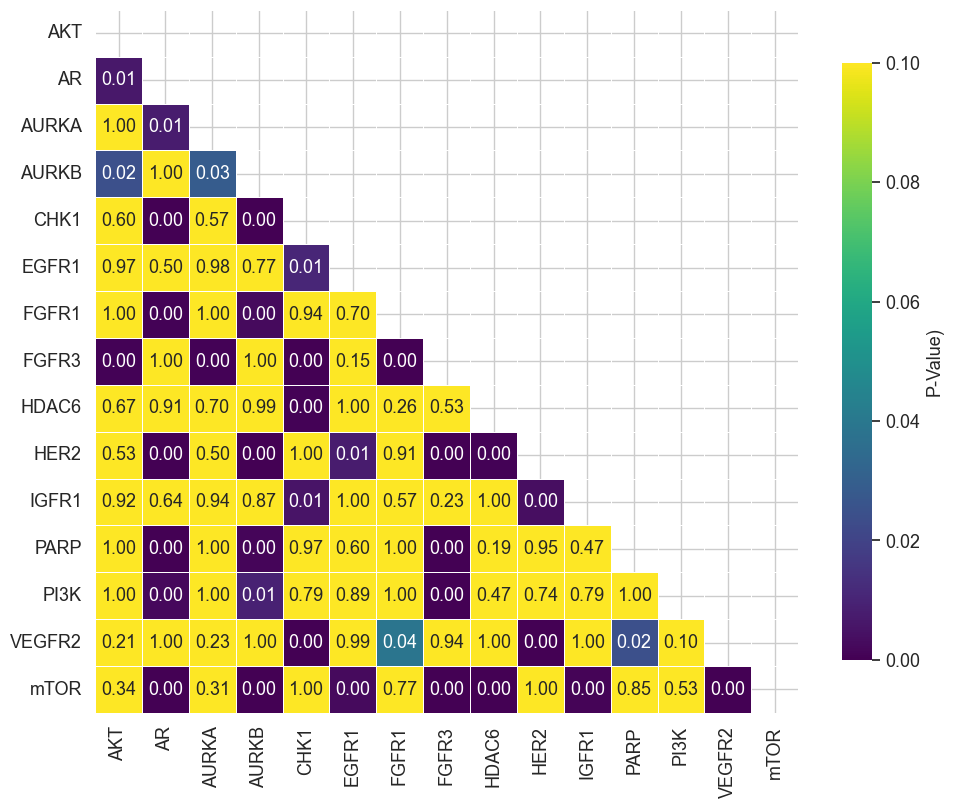

   🖼️  Saved Plot: DATASET_NEMENYI_PLOT.png


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp 
from pathlib import Path

def run_nemenyi_flexible(df, group_col, block_col, metric='R2', output_dir='.', filename_prefix=None):
    """
    Generic function to run Nemenyi Test with Viridis, 600 DPI, No Title, and Font Size 13.
    """
    # 1. Setup Output
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    
    # Determine label (e.g., CHEMICAL vs REPRESENTATION)
    file_label = filename_prefix if filename_prefix else group_col.upper()
    
    # 2. Aggregation 
    df_agg = df.groupby([block_col, group_col])[metric].mean().reset_index()

    # 3. Pivot
    pivot = df_agg.pivot_table(index=block_col, columns=group_col, values=metric)

    # 4. Handle Missing Data
    n_blocks = len(pivot)
    completeness = pivot.notna().sum()
    valid_groups = completeness[completeness == n_blocks].index
    
    if len(valid_groups) < 3:
        print(f"⚠️ Skipped {file_label}: Need 3+ groups with 100% coverage.")
        return None

    pivot_clean = pivot[valid_groups]
    
    if len(valid_groups) > 50:
        print(f"⚠️ High dimension warning: Comparing {len(valid_groups)} items.")

    print(f"✅ Running Nemenyi on {len(valid_groups)} {file_label}s.")

    # 5. Run Statistical Test
    try:
        p_values = sp.posthoc_nemenyi_friedman(pivot_clean)
    except Exception as e:
        print(f"Error running statistical test: {e}")
        return None

    # --- SAVE TABLE ---
    csv_name = f"{file_label}_NEMENYI_TABLE.csv"
    p_values.to_csv(out_path / csv_name)
    print(f"   📄 Saved Table: {csv_name}")

    # 6. Generate Heatmap
    fig_size = min(30, max(10, len(valid_groups) * 0.6)) # Slightly increased size for larger font
    plt.figure(figsize=(fig_size, fig_size * 0.85))
    
    mask = np.triu(np.ones_like(p_values, dtype=bool))
    
    # --- PLOT WITH FONT SIZE 13 ---
    ax = sns.heatmap(p_values, 
                mask=mask,
                annot=True if len(valid_groups) < 20 else False,
                fmt='.2f', 
                cmap='viridis', 
                vmin=0, vmax=0.1, 
                center=0.05, 
                square=True, 
                linewidths=0.5, 
                cbar_kws={"shrink": 0.8}, # Adjust colorbar size slightly
                annot_kws={"size": 13}) # FONT SIZE 13 for numbers inside

    # --- FONT SIZE 13 FOR AXES ---
    plt.xticks(fontsize=13, rotation=90) # Rotate x-axis for readability
    plt.yticks(fontsize=13, rotation=0)

    # --- FONT SIZE 13 FOR COLORBAR ---
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13) # Font 13 for numbers on colorbar
    cbar.set_label("P-Value)", size=13) # Font 13 for label

    # NO TITLE
    plt.tight_layout()

    # --- SAVE PLOT (600 DPI) ---
    png_name = f"{file_label}_NEMENYI_PLOT.png"
    plt.savefig(out_path / png_name, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"   🖼️  Saved Plot: {png_name}")

def run_all_nemenyi_tests(df, metric='R2', output_dir='.'):
    """
    Runs Nemenyi tests for Model, Chemical, and Dataset.
    """
    print(f"--- STARTING STATISTICAL ANALYSIS ({metric}) ---")
    
    # 1. By MODEL
    run_nemenyi_flexible(df, group_col='model', block_col='dataset', 
                         metric=metric, output_dir=output_dir,
                         filename_prefix='MODEL')
    
    # 2. By CHEMICAL (Representation)
    if 'representation' in df.columns:
        run_nemenyi_flexible(df, group_col='representation', block_col='dataset', 
                             metric=metric, output_dir=output_dir,
                             filename_prefix='CHEMICAL') 

    # 3. By DATASET
    run_nemenyi_flexible(df, group_col='dataset', block_col='model', 
                         metric=metric, output_dir=output_dir,
                         filename_prefix='DATASET')

# --- Usage ---
# df = pd.read_csv('summary_results_external.csv') 
run_all_nemenyi_tests(df, metric='R2', output_dir='.')

## Wilcoxon Tests for Dataset, Model, and Chemical [**REVISED**]

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from itertools import combinations
from pathlib import Path

def calculate_pairwise_wilcoxon(pivot_df, metric_is_error=False):
    """
    Core function to calculate pairwise Wilcoxon tests from a pivot table.
    """
    items = pivot_df.columns
    results = []
    
    # Iterate through every unique pair of columns (Items)
    for item1, item2 in combinations(items, 2):
        # Get paired data (must drop NaNs to align pairs)
        data = pivot_df[[item1, item2]].dropna()
        
        # We need at least ~5 data points to get a meaningful p-value
        if len(data) < 5:
            continue
            
        x = data[item1]
        y = data[item2]
        
        # Check if arrays are identical (Wilcoxon fails if difference is 0)
        if np.allclose(x, y):
            p_val = 1.0
            stat = 0
        else:
            try:
                stat, p_val = wilcoxon(x, y)
            except ValueError:
                # Happens if all differences are 0
                p_val = 1.0
        
        # Determine Winner
        mean1 = x.mean()
        mean2 = y.mean()
        
        if metric_is_error:
            # Lower is better (RMSE, MAE)
            better = item1 if mean1 < mean2 else item2
        else:
            # Higher is better (R2, Q2)
            better = item1 if mean1 > mean2 else item2
            
        results.append({
            'Item_A': item1,
            'Item_B': item2,
            'N_Pairs': len(data),
            'Mean_A': mean1,
            'Mean_B': mean2,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Better_Item': better
        })
        
    return pd.DataFrame(results)

def generate_wilcoxon_tables(df, metric='R2', output_dir='.'):
    """
    Generates Wilcoxon comparison tables for Model, Dataset, and Representation.
    """
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    print(f"--- Running Pairwise Wilcoxon Tests ({metric}) ---")
    
    # Determine if metric is an error (Lower = Better)
    is_error = metric in ['RMSE', 'MAE', 'MSE']

    # ==========================================
    # 1. MODEL COMPARISON (Paired by Dataset)
    # ==========================================
    print("1. Processing Models...")
    # Pivot: Index=Dataset (the pair ID), Columns=Model
    pivot_model = df.pivot_table(index='dataset', columns='model', values=metric, aggfunc='max')
    
    res_model = calculate_pairwise_wilcoxon(pivot_model, metric_is_error=is_error)
    if not res_model.empty:
        # Sort by P-Value (most significant differences first)
        res_model = res_model.sort_values('P_Value')
        res_model.to_csv(out_path / "MODEL_WILCOXON_TABLE.csv", index=False)
        print(f"   ✅ Saved: MODEL_WILCOXON_TABLE.csv ({len(res_model)} pairs)")

    # ==========================================
    # 2. CHEMICAL REPRESENTATION (Paired by Dataset)
    # ==========================================
    if 'representation' in df.columns:
        print("2. Processing Chemical Representations...")
        # Pivot: Index=Dataset, Columns=Representation
        # We average across models to get a 'general' score for that representation on that dataset
        pivot_rep = df.pivot_table(index='dataset', columns='representation', values=metric, aggfunc='mean')
        
        res_rep = calculate_pairwise_wilcoxon(pivot_rep, metric_is_error=is_error)
        if not res_rep.empty:
            res_rep = res_rep.sort_values('P_Value')
            res_rep.to_csv(out_path / "CHEMICAL_WILCOXON_TABLE.csv", index=False)
            print(f"   ✅ Saved: CHEMICAL_WILCOXON_TABLE.csv ({len(res_rep)} pairs)")
    else:
        print("   ⚠️ Skipped Chemical: 'representation' column not found.")

    # ==========================================
    # 3. DATASET COMPARISON (Paired by Model)
    # ==========================================
    # Comparison: Is Dataset A consistently harder/easier than Dataset B across models?
    print("3. Processing Datasets...")
    # Pivot: Index=Model, Columns=Dataset
    pivot_data = df.pivot_table(index='model', columns='dataset', values=metric, aggfunc='max')
    
    # Warning for high dimensionality
    if len(pivot_data.columns) > 30:
        print(f"   ⚠️ High dimensionality: {len(pivot_data.columns)} datasets. This may take a moment...")
    
    res_data = calculate_pairwise_wilcoxon(pivot_data, metric_is_error=is_error)
    if not res_data.empty:
        res_data = res_data.sort_values('P_Value')
        res_data.to_csv(out_path / "DATASET_WILCOXON_TABLE.csv", index=False)
        print(f"   ✅ Saved: DATASET_WILCOXON_TABLE.csv ({len(res_data)} pairs)")

    print(f"\n📂 All tables saved to: {out_path.absolute()}")

In [33]:
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')
generate_wilcoxon_tables(df, metric='R2')

--- Running Pairwise Wilcoxon Tests (R2) ---
1. Processing Models...
   ✅ Saved: MODEL_WILCOXON_TABLE.csv (66 pairs)
2. Processing Chemical Representations...
   ✅ Saved: CHEMICAL_WILCOXON_TABLE.csv (78 pairs)
3. Processing Datasets...
   ✅ Saved: DATASET_WILCOXON_TABLE.csv (105 pairs)

📂 All tables saved to: c:\Users\raula\Documents\QSAR\figures


## Ranking Stability and Boostrap Ranking Distribution [**REVISED**]

📂 Saving Absolute Rank Analysis to: c:\Users\raula\Documents\QSAR\figures

--- Analyzing Absolute Ranks: MODEL (judged by dataset) ---
   ✅ Ranking 12 models across 15 datasets.
   📄 Saved Table: MODEL_STABILITY_TABLE.csv


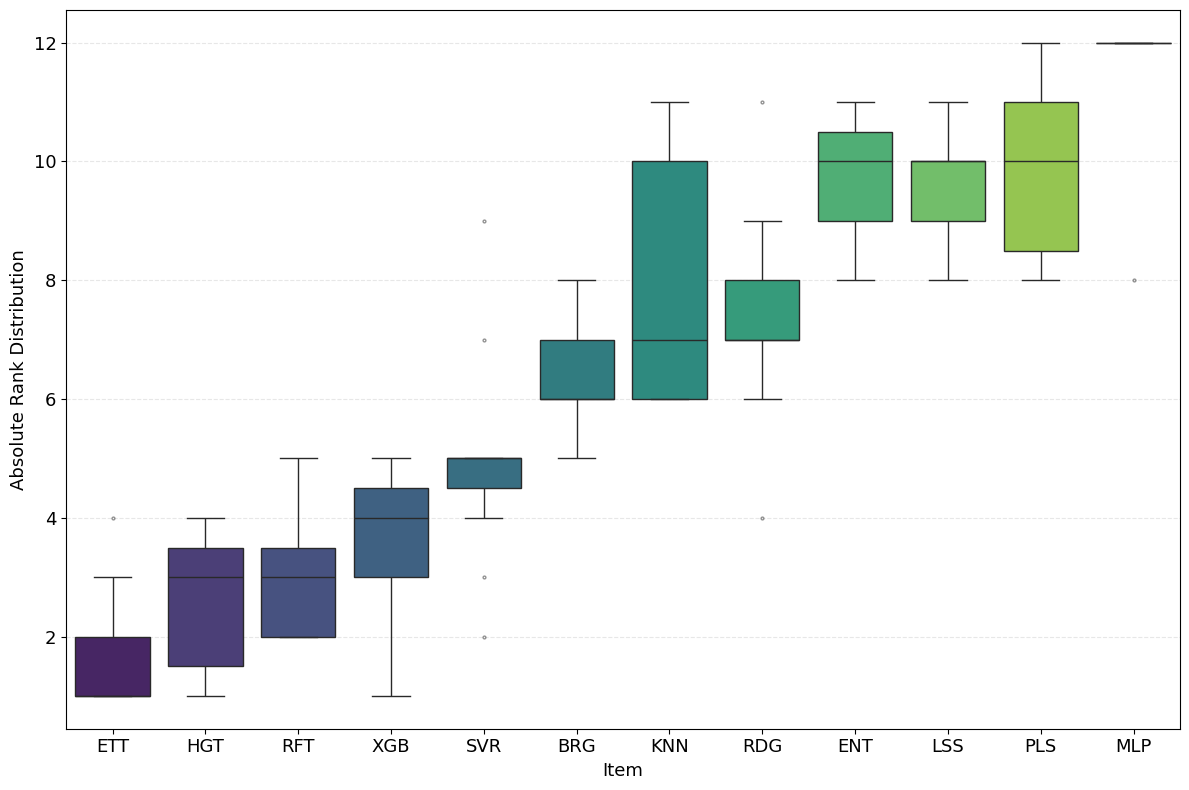

   🖼️  Saved Plot: MODEL_STABILITY_PLOT.png

--- Analyzing Absolute Ranks: DATASET (judged by model) ---
   ✅ Ranking 15 datasets across 12 models.
   📄 Saved Table: DATASET_STABILITY_TABLE.csv


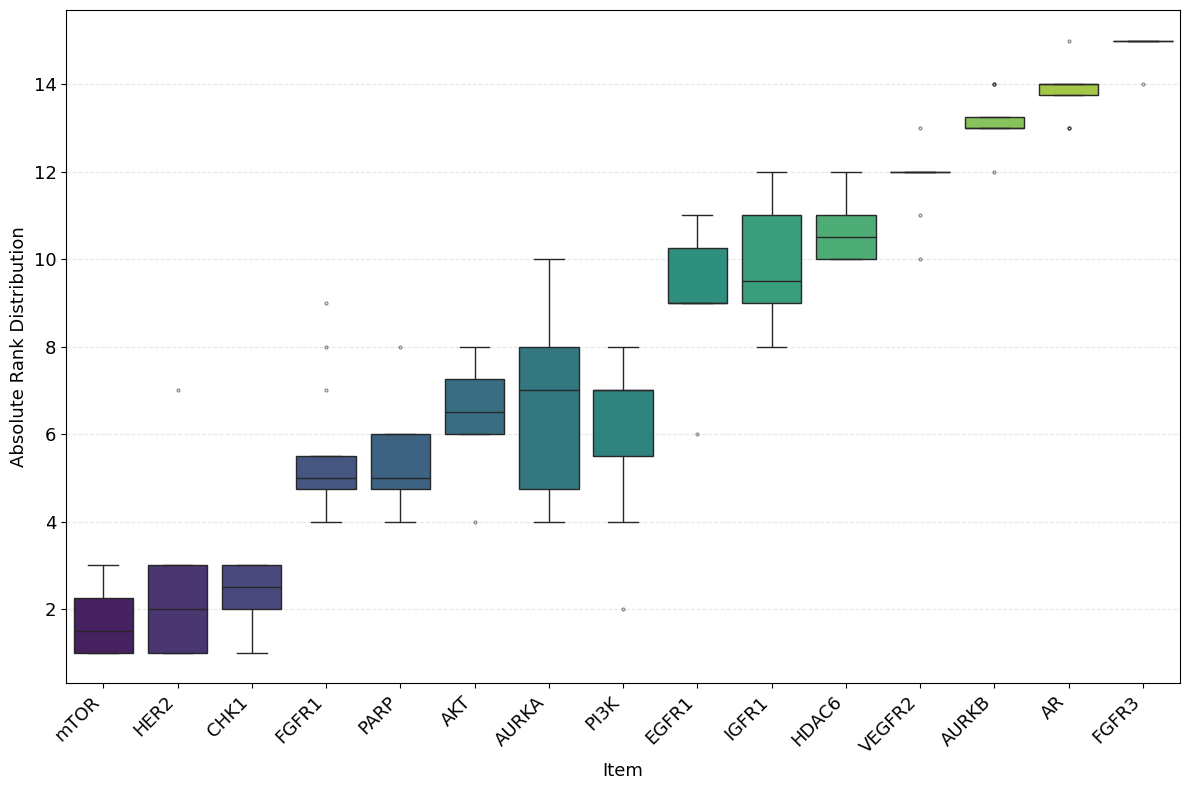

   🖼️  Saved Plot: DATASET_STABILITY_PLOT.png

--- Analyzing Absolute Ranks: REPRESENTATION (judged by dataset) ---
   ✅ Ranking 12 representations across 15 datasets.
   📄 Saved Table: CHEMICAL_STABILITY_TABLE.csv


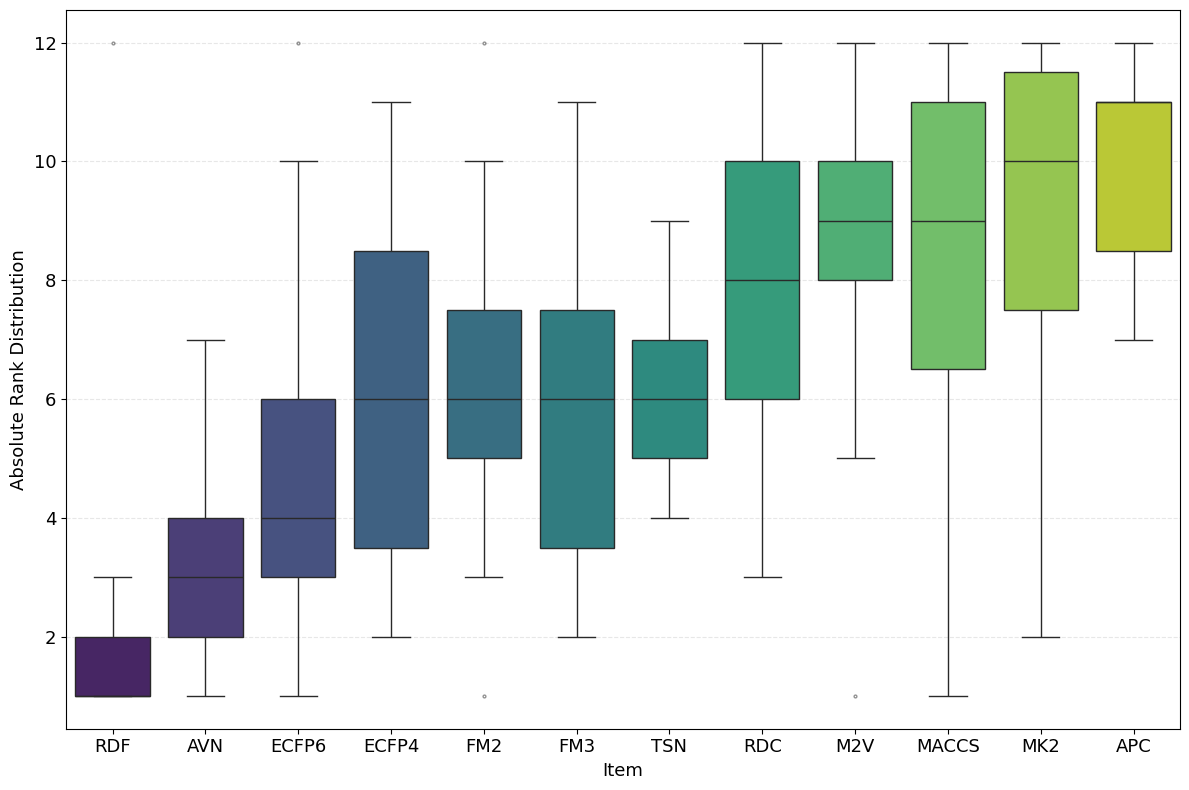

   🖼️  Saved Plot: CHEMICAL_STABILITY_PLOT.png


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def calculate_absolute_ranks(pivot_df, metric_is_error=False):
    """
    Calculates the absolute rank of each item for every judge (row).
    
    Args:
        pivot_df: Rows = Judges (Datasets), Columns = Items (Models/Rep).
        metric_is_error: If True (RMSE), low values = Rank 1. 
                         If False (R2), high values = Rank 1.
    Returns:
        DataFrame of ranks (same shape as pivot_df).
    """
    # If metric is Error (RMSE), Ascending=True (Lowest is #1)
    # If metric is Score (R2), Ascending=False (Highest is #1)
    return pivot_df.rank(axis=1, ascending=metric_is_error, method='min')

def plot_rank_distributions(rank_df, filename, output_dir, subject_type):
    """
    Plots the rank distribution (absolute ranks across datasets).
    """
    # Sort by Median Rank (Best on Left/Top)
    median_ranks = rank_df.median().sort_values()
    sorted_df = rank_df[median_ranks.index]
    
    n_items = len(sorted_df.columns)
    
    if n_items > 50:
        print(f"⚠️ Too many items ({n_items}) for boxplot. Plotting Top 30 only.")
        sorted_df = sorted_df.iloc[:, :30]
        n_items = 30

    fig_width = max(12, n_items * 0.4)
    plt.figure(figsize=(fig_width, 8))
    
    # Create Boxplot
    sns.boxplot(data=sorted_df, palette="viridis", flierprops={"marker": "o", "markersize": 2, "alpha": 0.5})
    
    plt.ylabel('Absolute Rank Distribution', fontsize=13)
    plt.xlabel('Item', fontsize=13)
    
    # Rotation logic based on subject type
    if subject_type == 'dataset':
        plt.xticks(rotation=45, ha='right', fontsize=13)
    else:
        plt.xticks(rotation=0, fontsize=13) 
    
    plt.yticks(fontsize=13)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=600, bbox_inches='tight')
    plt.show()

def analyze_ranking_stability(df, metric='R2', output_dir='.', representation_map=None, model_name_map=None):
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    print(f"📂 Saving Absolute Rank Analysis to: {out_path.absolute()}")

    is_error = metric in ['RMSE', 'MAE', 'MSE']

    # Apply mappings
    if representation_map:
        if 'representation' in df.columns:
            df['representation'] = df['representation'].map(representation_map).fillna(df['representation'])
    if model_name_map:
        if 'model' in df.columns:
            df['model'] = df['model'].map(model_name_map).fillna(df['model'])
    
    # Define the 3 Scenarios
    scenarios = [
        # (Target, Judge, Filename_Prefix)
        ('model', 'dataset', 'MODEL'),
        ('dataset', 'model', 'DATASET'),
    ]
    
    if 'representation' in df.columns:
        scenarios.append(('representation', 'dataset', 'CHEMICAL'))

    for subject, judge, prefix in scenarios:
        if subject not in df.columns or judge not in df.columns:
            continue

        print(f"\n--- Analyzing Absolute Ranks: {subject.upper()} (judged by {judge}) ---")
        
        # Aggregate mean in case of duplicates, then pivot
        df_agg = df.groupby([judge, subject])[metric].mean().reset_index()
        pivot = df_agg.pivot_table(index=judge, columns=subject, values=metric)
        
        # Filter for completeness (optional, but good for fair ranking)
        n_judges = len(pivot)
        valid_cols = pivot.notna().sum() == n_judges
        
        if valid_cols.sum() < 2:
            print(f"   ⚠️ Not enough {subject}s with 100% coverage. Skipping.")
            continue
            
        pivot_clean = pivot.loc[:, valid_cols]
        print(f"   ✅ Ranking {valid_cols.sum()} {subject}s across {n_judges} {judge}s.")
        
        # --- CHANGED: Calculate Absolute Ranks ---
        # Rows = Datasets, Columns = Models. Values = Rank (1, 2, 3...)
        rank_matrix = calculate_absolute_ranks(pivot_clean, metric_is_error=is_error)
        
        # Save Table (Statistics of the ranks)
        summary = rank_matrix.agg(['mean', 'std', 'min', 'max', 'median']).T
        summary = summary.sort_values('median')
        
        csv_name = f"{prefix}_STABILITY_TABLE.csv"
        summary.to_csv(out_path / csv_name)
        print(f"   📄 Saved Table: {csv_name}")
        
        # Plot
        plot_name = f"{prefix}_STABILITY_PLOT.png"
        plot_rank_distributions(rank_matrix, plot_name, out_path, subject_type=subject)
        
        print(f"   🖼️  Saved Plot: {plot_name}")

# --- Usage ---
# df = pd.read_csv('your_data.csv') 

model_name_map = {
    'ElasticNet': 'ENT', 'ExtraTrees': 'ETT', 'HistGBDT': 'HGT',
    'Lasso': 'LSS', 'PLSRegression': 'PLS', 'RandomForest': 'RFT',
    'Ridge': 'RDG', 'SVR_rbf': 'SVR', 'XGBoost': 'XGB', 'BayesianRidge': 'BRG'
}

representation_map = {
    'AtomPair_counts': 'APC', 'Avalon': 'AVN', 'FeatMorgan2': 'FM2',
    'FeatMorgan3': 'FM3', 'Mol2Vec_Embeddings': 'M2V',
    'Mordred_2D_Chi_Kappa_EState': 'MK2', 'RDKFingerprint': 'RDF',
    'Rdkit_PhysChem': 'RDC', 'Spectrophore_USRCAT': 'SUT', 'Torsion': 'TSN'
}

analyze_ranking_stability(df, metric='R2', output_dir='.', representation_map=representation_map, model_name_map=model_name_map)

## T-test for Models, Chemical, and Daatasets [**REVISED**]

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from itertools import combinations
from pathlib import Path

def calculate_pairwise_ttest(pivot_df, metric_is_error=False):
    """
    Calculates pairwise Paired T-Tests (Student's t-test) from a pivot table.
    """
    items = pivot_df.columns
    results = []
    
    # Iterate through every unique pair
    for item1, item2 in combinations(items, 2):
        data = pivot_df[[item1, item2]].dropna()
        
        if len(data) < 2: continue
            
        x = data[item1]
        y = data[item2]
        
        if np.allclose(x, y):
            p_val, t_stat = 1.0, 0.0
        else:
            t_stat, p_val = ttest_rel(x, y)
        
        # Round p-value to 2 decimal places
        p_val = round(p_val, 2)
        
        # Determine Winner
        mean1, mean2 = x.mean(), y.mean()
        if metric_is_error:
            better = item1 if mean1 < mean2 else item2
        else:
            better = item1 if mean1 > mean2 else item2
            
        results.append({
            'Item_A': item1, 'Item_B': item2,
            'P_Value': p_val, 'Better_Item': better
        })
        
    return pd.DataFrame(results)

def plot_ttest_matrix_viridis(results_df, category_name, output_dir):
    """
    Converts list of results into a Square Matrix and plots a P-Value Heatmap.
    Uses VIRIDIS colormap.
    """
    if results_df.empty: return

    # 1. Get all unique items to build the matrix index
    items = sorted(list(set(results_df['Item_A']) | set(results_df['Item_B'])))

    matrix = pd.DataFrame(index=items, columns=items, dtype=float)
    
    # 2. Fill Matrix (Symmetric)
    for _, row in results_df.iterrows():
        a, b, p = row['Item_A'], row['Item_B'], row['P_Value']
        matrix.loc[a, b] = p
        matrix.loc[b, a] = p
    
    # Fill diagonal with 1.0 (no difference with self)
    np.fill_diagonal(matrix.values, 1.0)
    
    # 3. Plot
    n_items = len(items)
    fig_size = min(30, max(10, n_items * 0.6))
    plt.figure(figsize=(fig_size, fig_size * 0.85))
    
    # Mask upper triangle
    mask = np.triu(np.ones_like(matrix, dtype=bool))
    
    # --- VIRIDIS COLOR LOGIC ---
    # vmin=0, vmax=0.1 focuses the color gradient on the significance threshold.
    # 0.00 (Purple) = Significant Difference
    # 0.05 (Teal)   = Threshold
    # 0.10+ (Yellow)= No Difference
    heatmap = sns.heatmap(matrix, mask=mask, 
                          annot=True if n_items < 25 else False, # Hide numbers if too crowded
                          fmt='.2f',  # Format p-value to 2 decimals
                          cmap='viridis', 
                          vmin=0, vmax=0.1, 
                          square=True, linewidths=0.5,
                          cbar_kws={"label": "P-Value"})
    
    # Ajustar el tamaño de la fuente de las etiquetas de los ejes
    heatmap.set_xlabel('Items', fontsize=13)
    heatmap.set_ylabel('Items', fontsize=13)

    # Ajustar el tamaño de la fuente de la barra de colores
    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)  # Aumentar el tamaño de la fuente de la barra de color

    # Cambiar el tamaño de la etiqueta del colorbar
    cbar.set_label('P-Value', fontsize=13)  # Título de la barra de colores con tamaño de fuente ajustado

    # Ajustar las etiquetas de los ticks de los ejes
    heatmap.tick_params(axis='x', labelsize=13)
    heatmap.tick_params(axis='y', labelsize=13)
    
    plt.tight_layout()
    
    # Save
    out_path = Path(output_dir)
    filename = f"{category_name.upper()}_TTEST_PLOT.png"
    plt.savefig(out_path / filename, dpi=600, bbox_inches='tight')
    plt.show()
    print(f"   🖼️  Saved Plot: {filename}")

def generate_ttest_analysis_viridis(df, metric='R2', output_dir='.'):
    """
    Generates T-Test Tables AND Matrices for Model, Dataset, and Representation.
    """
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    print(f"--- Running Pairwise T-Tests (Viridis Style) ---")
    
    is_error = metric in ['RMSE', 'MAE', 'MSE']
    
    # Define tasks: (Category Name, Pivot Index, Pivot Columns, AggFunc)
    tasks = [
        ('MODEL', 'dataset', 'model', 'max'),
        ('DATASET', 'model', 'dataset', 'max')
    ]
    if 'representation' in df.columns:
        tasks.append(('CHEMICAL', 'dataset', 'representation', 'mean'))

    for category, p_index, p_cols, p_agg in tasks:
        print(f"\nProcessing {category}...")
        
        # 1. Pivot
        pivot = df.pivot_table(index=p_index, columns=p_cols, values=metric, aggfunc=p_agg)
        
        # 2. Check size
        if len(pivot.columns) > 50:
            print(f"   ⚠️ Large dimension ({len(pivot.columns)} items). Matrix may be crowded.")

        # 3. Calculate
        res_df = calculate_pairwise_ttest(pivot, metric_is_error=is_error)
        
        if not res_df.empty:
            # 4. Save Table
            csv_name = f"{category}_TTEST_TABLE.csv"
            res_df.sort_values('P_Value').to_csv(out_path / csv_name, index=False)
            print(f"   📄 Saved Table: {csv_name}")
            
            # 5. Generate & Save Matrix Plot
            plot_ttest_matrix_viridis(res_df, category, out_path)
        else:
            print(f"   ⚠️ Not enough data for {category} t-tests.")


--- Running Pairwise T-Tests (Viridis Style) ---

Processing MODEL...
   📄 Saved Table: MODEL_TTEST_TABLE.csv


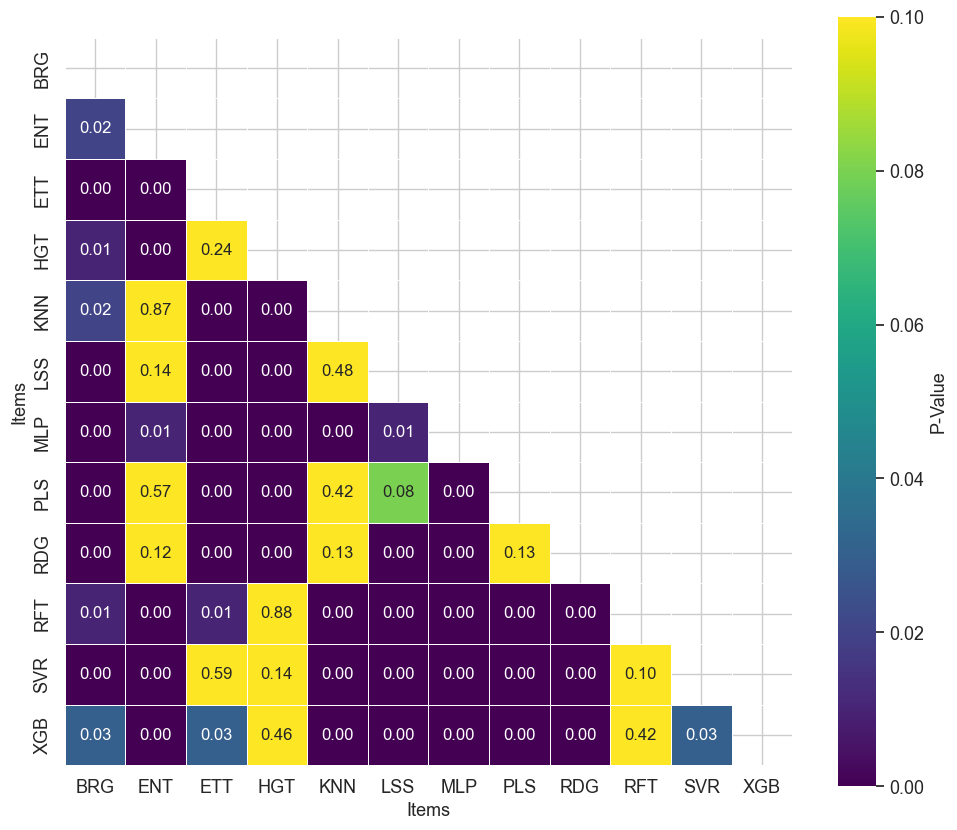

   🖼️  Saved Plot: MODEL_TTEST_PLOT.png

Processing DATASET...
   📄 Saved Table: DATASET_TTEST_TABLE.csv


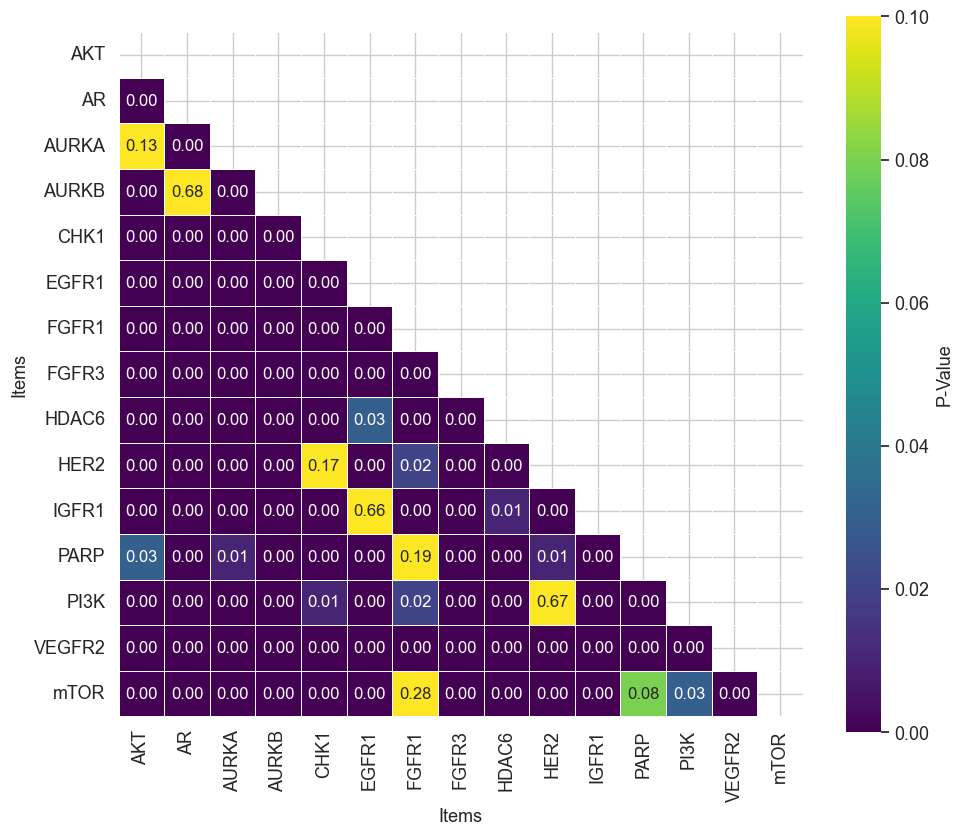

   🖼️  Saved Plot: DATASET_TTEST_PLOT.png

Processing CHEMICAL...
   📄 Saved Table: CHEMICAL_TTEST_TABLE.csv


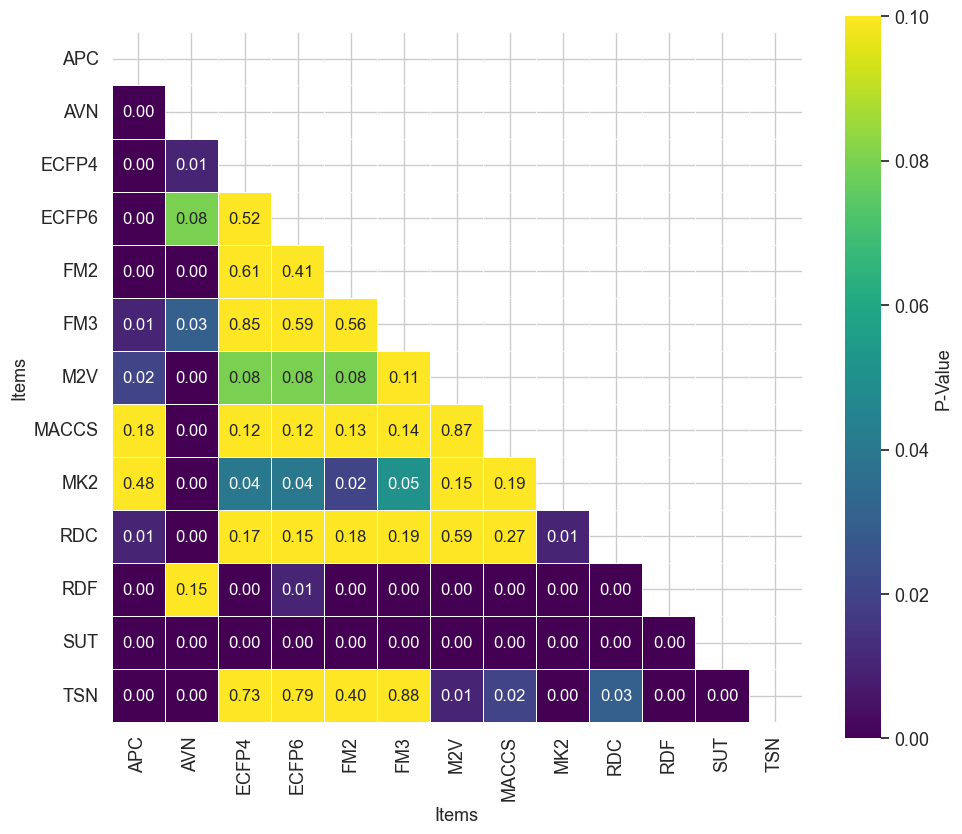

   🖼️  Saved Plot: CHEMICAL_TTEST_PLOT.png


In [36]:
# --- Usage ---
# df = pd.read_csv('summary_results_external.csv')
generate_ttest_analysis_viridis(df, metric='R2')

## Molecule Number and IC50

In [ ]:
import numpy as np

# IC50 and R2 values
ic50_values = np.array([3328, 4072, 6769, 4638, 4170, 5112, 4820, 3375, 3670, 16715, 4424, 2444, 14087, 3725, 2367, 6287])
r2_values = np.array([0.513, 0.572, 0.447, 0.565, 0.503, 0.584, 0.510, 0.016, 0.210, 0.424, 0.416, 0.574, 0.334, 0.492, 0.257, 0.400])

# Calculate Pearson correlation coefficient
correlation = np.corrcoef(ic50_values, r2_values)[0, 1]
print(f"Correlation coefficient: {correlation}")


Correlation coefficient: -0.03261491581134363


: 